In [73]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as T
import matplotlib.pyplot as plt
import mlflow.pytorch
from torch.utils.data import DataLoader, Subset
import numpy as np

from pathlib import Path
from src.training.load_config import load_config
from src.training.JDDDataset import JDDDataset
import matplotlib.pyplot as plt

# Read config
run_config = load_config()
outpath = Path(run_config['numpy_raw_subdir'])
alignment_csv =  outpath / run_config['align_csv']
dataset = JDDDataset(alignment_csv, validation=True, crop_size=256)
dataset = JDDDataset("bad_image_csv.csv", validation=True, crop_size=2058)

# dataset.csv = dataset.csv[~dataset.csv.bad]
# dataset.csv.reset_index(inplace=True)
    

In [74]:
def flatten(idx):
    out = dataset[idx]
    mask = out['deg'][3:]
    sparse = out['deg'][:3]
    gt = out['aligned']
    values = {}
    for i, c in enumerate(['r', 'g', 'b']):
        values[c] = {}
        values[c]['gt'] = gt[i][mask[i]==1]
        values[c]['inp'] = sparse[i][mask[i]==1]
    return values, out['iso'], out


In [75]:
from src.training.censored_fit import censored_linear_fit_twosided

In [76]:
def sample_fraction(gt, inp, fraction, seed=None, replace=False):
    """
    Sample the same subset of indices from two aligned arrays.

    Parameters
    ----------
    gt : array-like
        Ground truth array.
    inp : array-like
        Input array aligned with gt.
    fraction : float
        Fraction of events to sample (0 < fraction <= 1).
    seed : int or None
        Random seed for reproducibility.
    replace : bool
        Whether to sample with replacement.

    Returns
    -------
    gt_sampled : np.ndarray
    inp_sampled : np.ndarray
    indices : np.ndarray
        The sampled indices.
    """

    gt = np.asarray(gt)
    inp = np.asarray(inp)

    if len(gt) != len(inp):
        raise ValueError("gt and inp must have the same length")

    if not (0 < fraction <= 1):
        raise ValueError("fraction must be in (0, 1]")

    rng = np.random.default_rng(seed)

    n = len(gt)
    n_sample = int(np.ceil(n * fraction))

    indices = rng.choice(n, size=n_sample, replace=replace)

    return gt[indices], inp[indices], indices

In [81]:
import numpy as np

def r2_identity(gt, inp):
    """
    Compute R^2 score for a fixed y=x fit.

    Parameters
    ----------
    gt : array-like
        Ground truth values (y_true)
    inp : array-like
        Predicted/input values (y_pred)

    Returns
    -------
    r2 : float
        R^2 score relative to the identity model y=x
    """

    gt = np.asarray(gt, dtype=np.float64)
    inp = np.asarray(inp, dtype=np.float64)

    if gt.shape != inp.shape:
        raise ValueError("gt and inp must have the same shape")

    ss_res = np.sum((gt - inp) ** 2)
    ss_tot = np.sum((gt - np.mean(gt)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1.0 - (ss_res / ss_tot)

In [ ]:
from tqdm import tqdm 

channels = ['r', 'g', 'b']
colors = {'r': 'red', 'g': 'green', 'b': 'blue'}
fit_values = []

In [130]:

for i in tqdm(range(929, len(dataset))):
    try:
        flattened, iso, out = flatten(i)
        color_fits = dataset.csv.iloc[i].to_dict()
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

        for ax, ch in zip(axes, channels):
            gt = flattened[ch]['gt']
            inp = flattened[ch]['inp']
            gt, inp, _ = sample_fraction(gt, inp, 0.01)
            a, b, sigma = censored_linear_fit_twosided(gt, inp, clip_low=0, clip_high=1)
            color_fits[ch+"a"] = float(a)
            color_fits[ch+"b"] = float(b)
            color_fits[ch+"sigma"] = float(sigma)
            _gt = b * gt + a

            ax.scatter(
                gt,
                inp,
                s=4,
                alpha=0.3,
                color="black",
                edgecolors='none'
            )
            ax.scatter(
                _gt,
                inp,
                s=4,
                alpha=0.3,
                color=colors[ch],
                edgecolors='none'
            )
            max_val = max(max(gt), max(inp))
            x = np.linspace(0, max_val, 100)
            y  = b * x + a
            ax.plot(x, x, linestyle='--')
        plt.title(i)
        plt.savefig(f'plots/{i}.png')
        plt.close()
        color_fits['r2_after'] = color_fits['after'] = float(r2_identity(_gt, inp))
        color_fits['r2_before'] = float(r2_identity(gt, inp))
        color_fits['mean_after'] = float((_gt-inp).mean())
        color_fits['mean_before'] = float((gt-inp).mean())
        
    except:
        color_fits = dataset.csv.iloc[i].to_dict()
    fit_values.append(color_fits)


100%|██████████| 1232/1232 [30:30<00:00,  1.49s/it]


In [131]:
import pandas as pd
df = pd.DataFrame(fit_values)
df.to_csv("refit.csv")


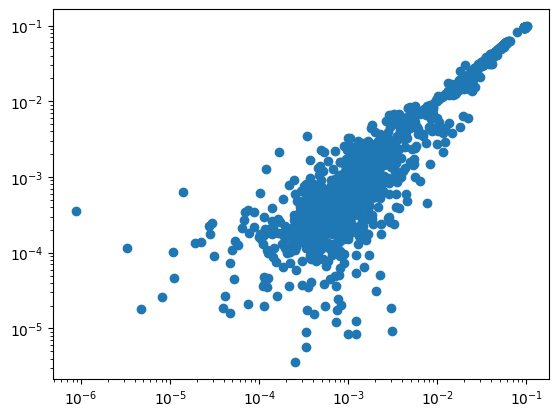

In [156]:
plt.scatter(df.ra, df.ga)
plt.yscale('log')
plt.xscale('log')


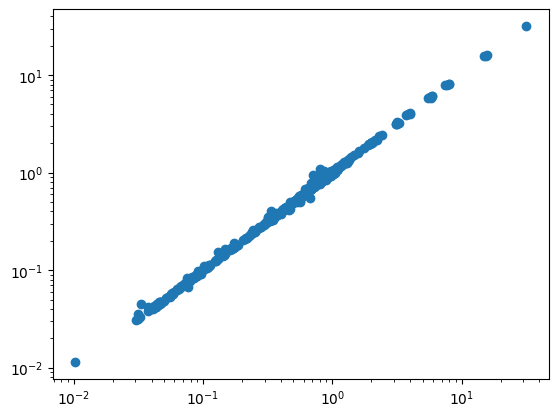

In [155]:
plt.scatter(df.rb, df.gb)
plt.yscale('log')
plt.xscale('log')


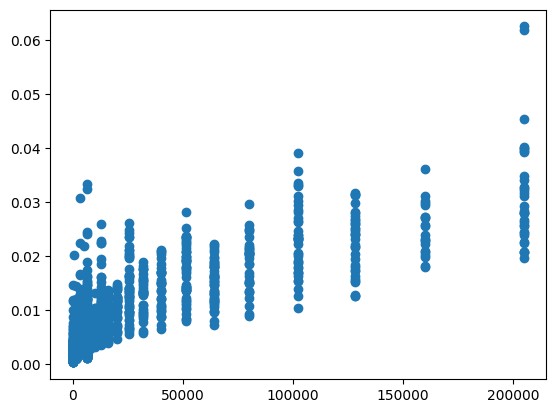

In [151]:
plt.scatter(df.iso, df.gsigma)
# plt.yscale('log')
# plt.xscale('log')

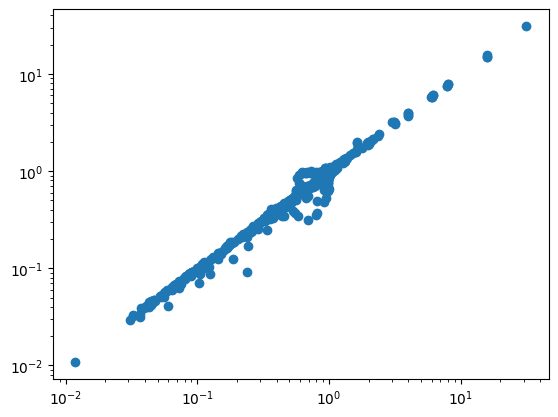

In [146]:
plt.scatter(df.b, df.bb)
plt.yscale('log')
plt.xscale('log')

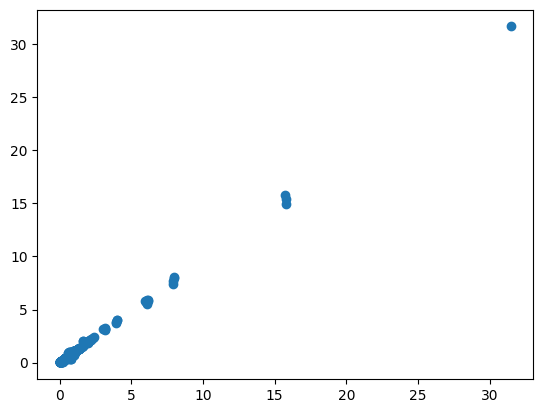

In [140]:
plt.scatter(df.b, df.rb)

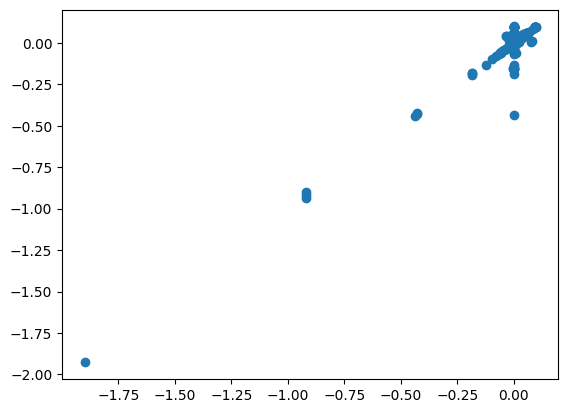

In [136]:
plt.scatter(df.a, df.ga)

<Axes: >

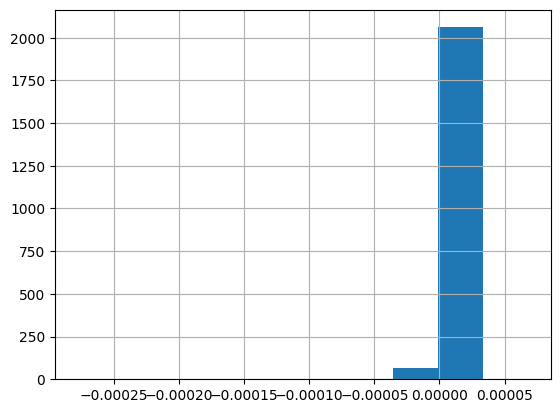

In [133]:
df.mean_after.hist()

<Axes: >

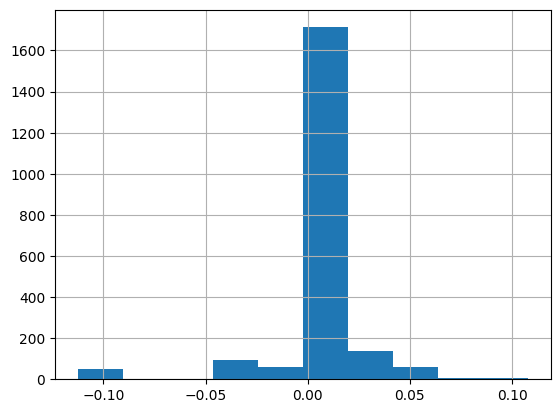

In [134]:
df.mean_before.hist()

In [72]:
dataset.csv.iloc[4].a, dataset.csv.iloc[4].b

(np.float64(0.000444141), np.float64(0.53143))

In [ ]:
c

(np.float32(0.030850941), np.float32(0.52206135))

In [122]:
out = dataset[22]

mask = out['deg'][3:]
sparse = out['deg'][:3]
gt = out['aligned'] * mask

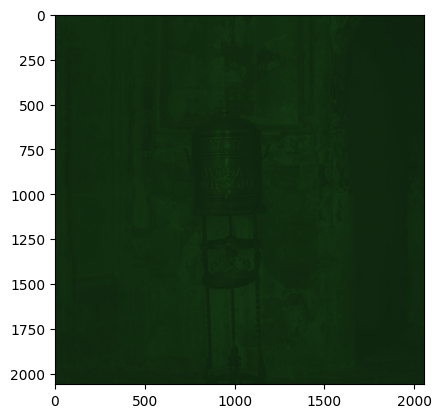

In [123]:
plt.imshow(gt.permute(1, 2, 0)**.5)

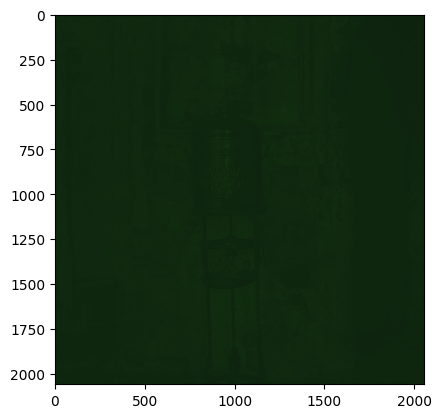

In [124]:
plt.imshow(sparse.permute(1, 2, 0)**.5)

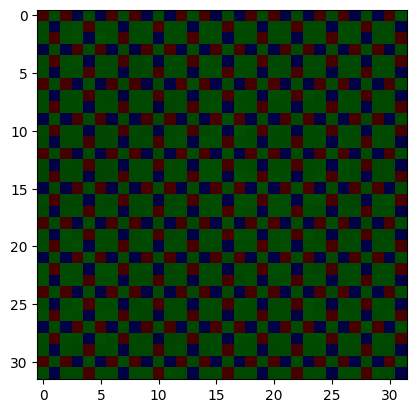

In [125]:
plt.imshow(sparse.permute(1, 2, 0)[0:32,0:32]**.5)

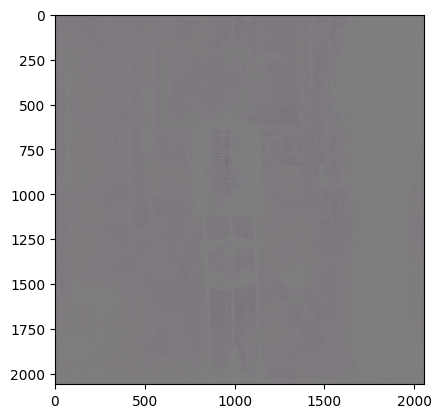

In [121]:
plt.imshow((sparse-gt).permute(1, 2, 0)+0.5)

In [ ]:

# --- Settings ---
RUN_ID = "afacbc329f0b4fedbb6d5d19e2074100"
NUM_SAMPLES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CFA_TYPE = "xtrans"

model_uri = f"runs:/{RUN_ID}/model"
print(f"Loading model from {model_uri}...")
model = mlflow.pytorch.load_model(model_uri).to(DEVICE)
model.eval()


In [ ]:
mask = sparse[0] > 0

plt.scatter(gt[0][mask],sparse[0][mask]-gt[0][mask], alpha =0.1),(sparse[0][mask]-gt[0][mask]).std()

In [ ]:
mask = sparse[2] > 0

plt.scatter(gt[2][mask],sparse[2][mask]-gt[2][mask], alpha =0.1), (sparse[2][mask]-gt[2][mask]).std()

In [ ]:
mask = sparse[1] > 0

plt.scatter(gt[1][mask],sparse[1][mask]-gt[1][mask], alpha =0.1), (sparse[1][mask]-gt[1][mask]).std()

In [ ]:
plt.imshow(sparse.permute(1, 2, 0)**.5)

In [ ]:
plt.imshow(gt.permute(1, 2, 0)**.5)

In [ ]:
from tqdm import tqdm
criterion = nn.L1Loss()
bad_is = []

def cut(iso, m=5e-8, b=0.01):
    return m * iso + b

losses = []
with torch.no_grad():
    # Use bfloat16 for inference if you trained with it
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        for i in tqdm(range(len(dataset))):
            data = dataset[i]
            row = dataset.csv.iloc[i].to_dict()
            sparse = data['deg'][:3]
            mask = data['deg'][3:]
            gt = data['aligned'] * mask
            loss = criterion(sparse, gt).item()
            iso = data['iso'].item()
            target_loss = cut(iso)
            row['loss'] = loss
            row['bad'] = loss > target_loss
            losses.append(row)
            if loss < target_loss: continue
            
            
            bad_is.append(i)
            # Plotting
            # axes[i, 2].imshow(img_sparse)
            # fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            # plt.subplots_adjust(hspace=0.4)

            # axes[2].imshow((gt-sparse).permute(1, 2, 0)*4+0.5)
            # axes[2].axis('off')

            # axes[0].imshow((gt).permute(1, 2, 0)**.5)
            # axes[0].axis('off')

            # axes[1].imshow((sparse).permute(1, 2, 0)**.5)
            # axes[1].axis('off')

            # axes[3].imshow((mask).permute(1, 2, 0)[0:32, 0:32])
            # axes[3].axis('off')

            # plt.tight_layout()
            # plt.show()



In [ ]:
import pandas as pd

df = pd.DataFrame(losses)

In [ ]:
plt.scatter( df.iso, df.loss)
_x = np.linspace(0, 200000)
def cut(iso, m=7e-8, b=0.006):
    return m * iso + b
plt.scatter(_x, cut(_x))

df.target_loss = cut(df.iso)
df.bad = df.loss > df.target_loss

In [ ]:
for x in df[df.bad].gt_out:
    print(x)

In [ ]:
df[df.bad].m12.hist()


In [ ]:
df[df.bad].m02.hist()

In [ ]:
df[df.bad & (df.b -1).abs() < .1].gt_out

In [ ]:
df[df.bad].b.hist(bins = np.linspace(0, 2, 100))

In [ ]:
df[~df.bad].b.hist(bins = np.linspace(0, 2, 100))

In [ ]:
len(bad_is)

In [ ]:
x = [x[0] for x in losses]
y = [x[1] for x in losses]
plt.scatter(y, x)
_x = np.linspace(0, 2000000)
def cut(iso, m=5e-8, b=0.01):
    return m * iso + b
plt.scatter(_x, cut(_x))

In [ ]:
for i in bad_is:
    if dataset.csv.iloc[i].b < .9: continue
    if dataset.csv.iloc[i].b > 1.1: continue

    print(i, dataset.csv.iloc[i].b)


In [ ]:
bad_is

In [ ]:
_csv = df[df.bad & (df.b -1).abs() < .1]

In [ ]:
dataset.csv = _csv

In [ ]:
from tqdm import tqdm
criterion = nn.L1Loss()
bad_is = []

def cut(iso, m=5e-8, b=0.01):
    return m * iso + b

losses = []
with torch.no_grad():
    # Use bfloat16 for inference if you trained with it
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        for i in tqdm(range(len(dataset))):
            data = dataset[i]
            row = dataset.csv.iloc[i].to_dict()
            sparse = data['deg'][:3]
            mask = data['deg'][3:]
            gt = data['aligned'] * mask
            loss = criterion(sparse, gt).item()
            # iso = data['iso'].item()
            # target_loss = cut(iso)
            # row['loss'] = loss
            # row['bad'] = loss > target_loss
            # losses.append(row)
            # if loss < target_loss: continue
            
            
            # bad_is.append(i)
            # Plotting
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            plt.subplots_adjust(hspace=0.4)

            axes[2].imshow((gt-sparse).permute(1, 2, 0)*4+0.5)
            axes[2].axis('off')

            axes[0].imshow((gt).permute(1, 2, 0)**.5)
            axes[0].axis('off')

            axes[1].imshow((sparse).permute(1, 2, 0)**.5)
            axes[1].axis('off')

            axes[3].imshow((mask).permute(1, 2, 0)[0:32, 0:32])
            axes[3].axis('off')

            plt.tight_layout()
            plt.show()



In [ ]:
# loader = DataLoader(dataset, batch_size=1, shuffle=False)
# criterion = nn.L1Loss()


# def cut(iso, m=5e-7, b=0.05):
#     return m * iso + b

# losses = []
# with torch.no_grad():
#     # Use bfloat16 for inference if you trained with it
#     with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
#         for i, data in enumerate(loader):
#             data = dataset[i]
#             gt, sparse = data['aligned'].to('cuda').unsqueeze(0), data['deg'].unsqueeze(0).to('cuda')
#             ccm = (data['ccm'].T).to('cuda').squeeze(-1).unsqueeze(0)
#             output = model(sparse)
#             loss = criterion(output, gt).item()
            
#             iso = data['iso'][0].item()
#             loss_cut = cut(iso)
#             if not loss > loss_cut: continue
#             losses.append((loss, iso))
#             # Convert to CPU and format for plotting [H, W, C]
#             img_gt = (gt.squeeze().permute(1, 2, 0)  @ ccm).cpu().float().clip(0,1)**.5
#             img_sparse = (sparse.squeeze()[:3].permute(1, 2, 0) @ ccm).cpu().float().numpy().clip(0,1)**.5
#             img_out = (output.squeeze().permute(1, 2, 0)  @ ccm).cpu().float().numpy().clip(0,1)**.5

#             # Clip values for visualization safety
#             img_out = np.clip(img_out, 0, 1)

#             # Plotting
#             # axes[i, 2].imshow(img_sparse)
#             fig, axes = plt.subplots(1, 3, figsize=(15, 5 * NUM_SAMPLES))
#             plt.subplots_adjust(hspace=0.4)

#             axes[2].imshow(img_gt-img_out+0.5)
#             axes[2].set_title(f"Input ({CFA_TYPE})")
#             axes[2].axis('off')

#             axes[0].imshow(img_out)
#             axes[0].set_title(f"Reconstruction\nL1 Loss: {loss:.4e}")
#             axes[0].axis('off')

#             axes[1].imshow(img_gt)
#             axes[1].set_title("Ground Truth")
#             axes[1].axis('off')

#             plt.tight_layout()
#             plt.show()
#             print(dataset.csv.iloc[i].gt_out)



In [ ]:
x = [x[0] for x in losses]
y = [x[1] for x in losses]

In [ ]:
x = [x[0] for x in losses]
y = [x[1] for x in losses]
plt.scatter(y, x)
_x = np.linspace(0, 2000000)
def cut(iso, m=5e-7, b=0.05):
    return m * iso + b
plt.scatter(_x, cut(_x))